In [1]:


# ## ASTraM Event Forecasting - Model Training
# 
# This notebook engineers historical rolling features, performs a time-based walk-forward split, and trains the Duration Regression and Closure Probability models.

In [2]:


import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, roc_auc_score, brier_score_loss
import shap
import os
import json
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)


# ## 1. Load Cleaned Data & Engineer Features

In [3]:

import sys
sys.path.append('../app')
from feature_engineering import engineer_features

df = pd.read_csv('../data/augmented_astram_events.csv')
df = engineer_features(df)
print(f"Loaded shape: {df.shape}")


# ## 3. Time-Based Walk-Forward Split
# We split the data by time to prevent future leakage. E.g., train on first 80% chronologically, test on last 20%.

Loaded shape: (7006, 55)


In [4]:


split_idx = int(len(df) * 0.8)
train_df_full = df.iloc[:split_idx].copy()
test_df_full = df.iloc[split_idx:].copy()

print(f"Train dates: {train_df_full['start_datetime'].min()} to {train_df_full['start_datetime'].max()}")
print(f"Test dates: {test_df_full['start_datetime'].min()} to {test_df_full['start_datetime'].max()}")


# ## 4. Modeling Setup

Train dates: 2023-11-09 19:24:48.154000+00:00 to 2024-03-13 05:20:55.448000+00:00
Test dates: 2024-03-13 05:22:56.176000+00:00 to 2024-04-08 17:11:42.780000+00:00


In [5]:


features = [
    'event_cause', 'corridor', 'priority', 
    'hour', 'dayofweek', 'is_weekend',
    'corridor_count_1d', 'corridor_count_7d', 'corridor_count_30d',
    'precipitation_mm',
    'osm_highway_class', 'osm_lanes', 'dist_to_nearest_road_m'
]

categorical_features = ['event_cause', 'corridor', 'priority', 'osm_highway_class']

# Fill NAs in categoricals
for col in categorical_features:
    train_df_full[col] = train_df_full[col].fillna('Unknown')
    test_df_full[col] = test_df_full[col].fillna('Unknown')

# Fill NAs in continuous/numeric OSM features
train_df_full['osm_lanes'] = train_df_full['osm_lanes'].fillna(2.0)
test_df_full['osm_lanes'] = test_df_full['osm_lanes'].fillna(2.0)

# Convert categoricals to Pandas category dtype so XGBoost uses native
# categorical splits instead of treating LabelEncoder ints as ordinals.
# Build a unified set of categories from both splits to ensure consistency.
category_mappings = {}
for col in categorical_features:
    all_cats = sorted(pd.concat([train_df_full[col], test_df_full[col]]).unique().tolist())
    cat_type = pd.CategoricalDtype(categories=all_cats, ordered=False)
    train_df_full[col] = train_df_full[col].astype(cat_type)
    test_df_full[col] = test_df_full[col].astype(cat_type)
    category_mappings[col] = all_cats

# Save category mappings for the app (replaces label_encoders.pkl)
with open('../models/category_mappings.json', 'w') as f:
    json.dump(category_mappings, f)
print('Category mappings saved. Categories per feature:')
for col, cats in category_mappings.items():
    print(f'  {col}: {len(cats)} categories')


# ## 5. Closure Probability Model
# Trained on the **FULL** dataset since `requires_road_closure` is well-populated.

Category mappings saved. Categories per feature:
  event_cause: 15 categories
  corridor: 23 categories
  priority: 2 categories
  osm_highway_class: 13 categories


In [6]:


X_train_closure = train_df_full[features]
y_train_closure = train_df_full['requires_road_closure'].astype(int)
X_test_closure = test_df_full[features]
y_test_closure = test_df_full['requires_road_closure'].astype(int)

closure_model = CatBoostClassifier(
    iterations=100, depth=4, learning_rate=0.1, random_state=42,
    cat_features=categorical_features, verbose=False
)
closure_model.fit(X_train_closure, y_train_closure)

preds_proba = closure_model.predict_proba(X_test_closure)[:, 1]
auc = roc_auc_score(y_test_closure, preds_proba)
brier = brier_score_loss(y_test_closure, preds_proba)

print(f"Closure Model AUC: {auc:.4f}")
print(f"Closure Model Brier Score: {brier:.4f}")

closure_model.save_model('../models/closure_model_cb.cbm')


# ## 6. Duration Regression Model
# Trained **ONLY** on the subset with valid duration labels.

Closure Model AUC: 0.8027
Closure Model Brier Score: 0.0540


In [7]:


train_df_dur = train_df_full.dropna(subset=['duration_minutes']).copy()
test_df_dur = test_df_full.dropna(subset=['duration_minutes']).copy()

X_train_dur = train_df_dur[features]
y_train_dur = np.log1p(train_df_dur['duration_minutes'])
X_test_dur = test_df_dur[features]
y_test_dur = test_df_dur['duration_minutes'] # Keep actuals for metric evaluation

duration_model = CatBoostRegressor(
    iterations=100, depth=4, learning_rate=0.1, random_state=42,
    cat_features=categorical_features, verbose=False
)
duration_model.fit(X_train_dur, y_train_dur)

# Predict and convert back from log space
preds_log = duration_model.predict(X_test_dur)
preds_minutes = np.expm1(preds_log)

mae = mean_absolute_error(y_test_dur, preds_minutes)
med_ae = median_absolute_error(y_test_dur, preds_minutes)

print(f"Duration Model MAE: {mae:.2f} minutes")
print(f"Duration Model Median AE: {med_ae:.2f} minutes")

error_by_cause = test_df_dur.assign(
    abs_error=np.abs(y_test_dur.values - preds_minutes)
).groupby('event_cause')['abs_error'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print("\nError Diagnostic by Event Cause:")
print(error_by_cause)

duration_model.save_model('../models/duration_model_cb.cbm')


# ## 7. SHAP Explainability

Duration Model MAE: 558.12 minutes
Duration Model Median AE: 100.61 minutes

Error Diagnostic by Event Cause:
                          mean       median  count
event_cause                                       
road_conditions    1541.027495  1722.473353     14
pot_holes          1461.889418  1564.054857     42
water_logging      1248.866465  1243.950932    119
public_event       1079.947976   493.059978      3
construction        962.372534   335.929599     44
tree_fall           830.976978   593.892842     76
others              825.535808   349.634183     49
procession          101.424599    62.764368      6
congestion           62.384417    56.079540      5
vehicle_breakdown    31.200802    23.647237    332
protest              26.244300    26.244300      1
accident             22.601060    19.454926     12


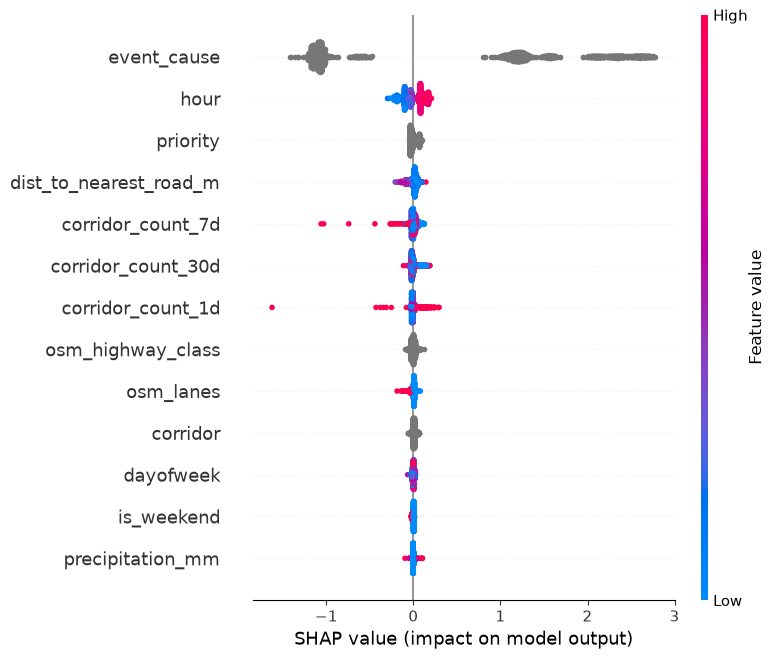

In [8]:


explainer = shap.TreeExplainer(duration_model)
shap_values = explainer.shap_values(X_train_dur)
shap.summary_plot(shap_values, X_train_dur, feature_names=features)